# Análisis de Vision Transformer (ViT)

**Asignatura:** 07MIAR Redes Neuronales y Deep Learning  
**Actividad:** Artículo C1   
**Alumno:** Marcos Antonio Lévano Huamaccto


## Objetivo

En este notebook se analiza una implementación preentrenada de la arquitectura
Vision Transformer (ViT), propuesta por Dosovitskiy et al. (2021) en el trabajo
*An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale*.

Se utilizará el modelo preentrenado `google/vit-base-patch16-224` mediante
PyTorch y Hugging Face Transformers.

El análisis se centrará en:

1. Examinar la arquitectura, capas e hiperparámetros del modelo.
2. Analizar la forma y distribución del tensor de entrada y los logits de salida.
3. Extraer y visualizar las activaciones de las capas de self-attention mediante
   mapas de calor para dos imágenes.

## 1. Arquitectura y resumen del modelo

In [ ]:
# Instalación
!pip install -q transformers torchinfo

In [ ]:
# Importación de librerias
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from torchinfo import summary

In [ ]:
# Comprobar el entorno
print("Versión de PyTorch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo disponible:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.11.0+cpu
Dispositivo disponible: cpu


In [ ]:
# Modelo seleccionado
MODEL_NAME = "google/vit-base-patch16-224"

print("Modelo seleccionado:")
print(MODEL_NAME)

Modelo seleccionado:
google/vit-base-patch16-224


## Modelo seleccionado: ViT-B/16

La arquitectura Vision Transformer representa una imagen como una secuencia de
patches. Para ViT-B/16, cada imagen se divide en regiones de 16×16 píxeles que
son transformadas en embeddings antes de ser procesadas por el Transformer
Encoder.

Para una imagen de 224×224 píxeles:

$$
N = \frac{224 \times 224}{16^2} = 196
$$

por lo que se obtienen 196 patches.

Además, se incorpora un token especial de clasificación `[CLS]`, dando como
resultado una secuencia de 197 tokens.

La variante ViT-Base utiliza:

- 12 bloques Transformer.
- Dimensión oculta de 768.
- 12 cabezas de atención.
- MLP de dimensión 3072.
- Aproximadamente 86 millones de parámetros.

### Carga del modelo preentrenado

Para el desarrollo de la actividad se utilizará una implementación preentrenada de
Vision Transformer (ViT), concretamente el modelo `google/vit-base-patch16-224`.

Esta implementación corresponde a la variante ViT-B/16, basada en la arquitectura
propuesta por Dosovitskiy et al. (2021). El modelo será cargado junto con su
procesador de imágenes asociado y se utilizará únicamente en modo inferencia.

Además, se habilitará una configuración compatible con la extracción posterior de
los pesos de self-attention, necesarios para generar los mapas de calor solicitados
en la actividad.

In [ ]:
# Cargar el procesador y modelo preentrenado

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
)

model = model.to(device)
model.eval()

print("Procesador y modelo cargados correctamente.")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Procesador y modelo cargados correctamente.


In [ ]:
# Inspección de la configuración del modelo

config = model.config

print("Arquitectura:", config.architectures)
print("Tamaño de imagen:", config.image_size)
print("Tamaño del patch:", config.patch_size)
print("Dimensión oculta:", config.hidden_size)
print("Número de capas Transformer:", config.num_hidden_layers)
print("Número de cabezas de atención:", config.num_attention_heads)
print("Dimensión de la capa MLP:", config.intermediate_size)
print("Número de clases:", config.num_labels)

Arquitectura: ['ViTForImageClassification']
Tamaño de imagen: 224
Tamaño del patch: 16
Dimensión oculta: 768
Número de capas Transformer: 12
Número de cabezas de atención: 12
Dimensión de la capa MLP: 3072
Número de clases: 1000


In [ ]:
# Número total de parámetros del modelo

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales: 86,567,656
Parámetros entrenables: 86,567,656


### Interpretación

El modelo ViT-B/16 contiene aproximadamente 86 millones de parámetros,
valor coherente con la configuración ViT-Base descrita en el artículo original.

Aunque los parámetros del modelo son entrenables, en esta actividad se utiliza
el modelo únicamente en modo inferencia, por lo que no se realizará ningún
proceso de ajuste o entrenamiento.

In [ ]:
# Resumen de la arquitectura del modelo

summary(
    model,
    input_size=(1, 3, 224, 224),
    depth=4,
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
ViTForImageClassification                          [1, 3, 224, 224]          [1, 1000]                 --                        True
├─ViTModel: 1-1                                    [1, 3, 224, 224]          [1, 197, 768]             --                        True
│    └─ViTEmbeddings: 2-1                          [1, 3, 224, 224]          [1, 197, 768]             152,064                   True
│    │    └─ViTPatchEmbeddings: 3-1                [1, 3, 224, 224]          [1, 196, 768]             --                        True
│    │    │    └─Conv2d: 4-1                       [1, 3, 224, 224]          [1, 768, 14, 14]          590,592                   True
│    │    └─Dropout: 3-2                           [1, 197, 768]             [1, 197, 768]             --                        --
│    └─ModuleList: 2-2                             --      

### Interpretación del resumen del modelo

El resumen de la arquitectura confirma que el modelo recibe tensores de entrada
con dimensión `[1, 3, 224, 224]`. La etapa de *patch embedding* transforma la
imagen en 196 representaciones de dimensión 768.

Al incorporar el token especial de clasificación `[CLS]`, la secuencia procesada
por el Transformer queda representada por un tensor de dimensión
`[1, 197, 768]`.

Finalmente, la cabeza de clasificación transforma la representación asociada al
token `[CLS]` en un vector de 1000 valores, correspondiente a los logits de las
1000 clases de ImageNet.

El modelo contiene 86.567.656 parámetros.

## 2. Tensor de entrada y logits

### 2.1. Ejemplo 1: imagen de un ave

Tamaño original: (1763, 1549)
Modo de color: RGB


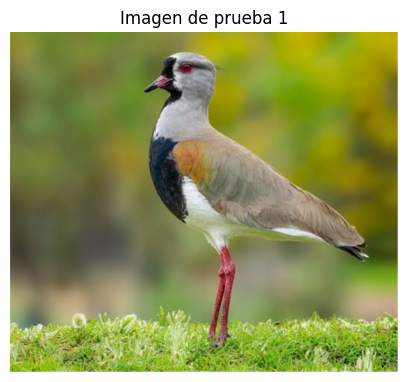

In [ ]:
# Cargar y visualizar la primera imagen

image_1 = Image.open("imagen_queltehue1.jpg").convert("RGB")

print("Tamaño original:", image_1.size)
print("Modo de color:", image_1.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image_1)
plt.axis("off")
plt.title("Imagen de prueba 1")
plt.show()

In [ ]:
# Preprocesamiento de la imagen

inputs_1 = processor(images=image_1,return_tensors="pt")

pixel_values_1 = inputs_1["pixel_values"]

print("Forma del tensor de entrada:", pixel_values_1.shape)
print("Tipo de datos:", pixel_values_1.dtype)
print("Valor mínimo:", pixel_values_1.min().item())
print("Valor máximo:", pixel_values_1.max().item())
print("Media:", pixel_values_1.mean().item())
print("Desviación estándar:", pixel_values_1.std().item())

Forma del tensor de entrada: torch.Size([1, 3, 224, 224])
Tipo de datos: torch.float32
Valor mínimo: -1.0
Valor máximo: 0.9372549057006836
Media: -0.12090960890054703
Desviación estándar: 0.3809126615524292


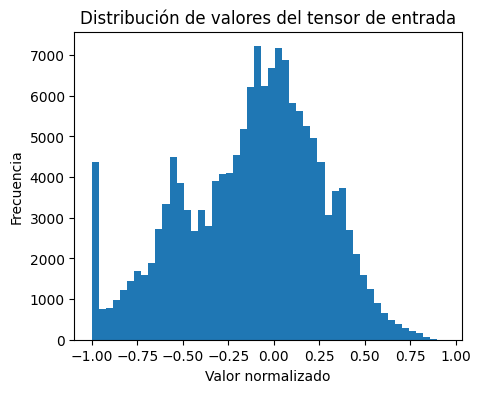

In [ ]:
# Distribución de valores del tensor de entrada

values_1 = pixel_values_1.cpu().numpy().flatten()

plt.figure(figsize=(5, 4))
plt.hist(values_1, bins=50)
plt.title("Distribución de valores del tensor de entrada")
plt.xlabel("Valor normalizado")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Inferencia y obtención de logits

pixel_values_1 = pixel_values_1.to(device)

with torch.no_grad():
    outputs_1 = model(pixel_values=pixel_values_1)

logits_1 = outputs_1.logits

print("Forma de los logits:", logits_1.shape)
print("Tipo de datos:", logits_1.dtype)
print("Valor mínimo:", logits_1.min().item())
print("Valor máximo:", logits_1.max().item())
print("Media:", logits_1.mean().item())
print("Desviación estándar:", logits_1.std().item())

Forma de los logits: torch.Size([1, 1000])
Tipo de datos: torch.float32
Valor mínimo: -2.1830549240112305
Valor máximo: 7.169622421264648
Media: -0.00021907138579990715
Desviación estándar: 1.0398904085159302


In [ ]:
# Convertir logits en probabilidades y obtener Top-5

probabilities_1 = torch.softmax(logits_1, dim=1)

top5_probs, top5_indices = torch.topk(probabilities_1, k=5, dim=1)

print("Top-5 predicciones:\n")

for i in range(5):
    class_id = top5_indices[0, i].item()
    probability = top5_probs[0, i].item()
    class_name = model.config.id2label[class_id]

    print(
        f"{i+1}. {class_name} "
        f"- probabilidad: {probability:.4f} "
        f"({probability*100:.2f}%)"
    )

Top-5 predicciones:

1. partridge - probabilidad: 0.2409 (24.09%)
2. black grouse - probabilidad: 0.1011 (10.11%)
3. prairie chicken, prairie grouse, prairie fowl - probabilidad: 0.0950 (9.50%)
4. black stork, Ciconia nigra - probabilidad: 0.0705 (7.05%)
5. European gallinule, Porphyrio porphyrio - probabilidad: 0.0467 (4.67%)


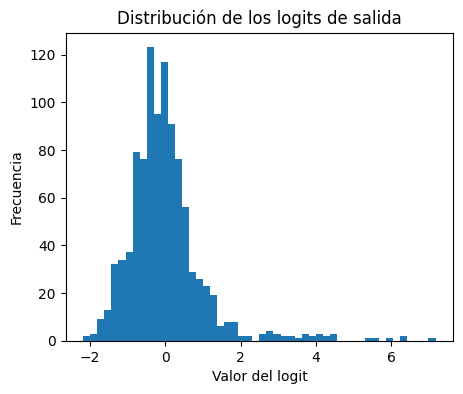

In [ ]:
# Distribución de los logits de salida

logit_values_1 = logits_1.detach().cpu().numpy().flatten()

plt.figure(figsize=(5, 4))
plt.hist(logit_values_1, bins=50)
plt.title("Distribución de los logits de salida")
plt.xlabel("Valor del logit")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación de los logits

El modelo genera un vector de 1000 logits, uno por cada clase de ImageNet.
Los valores no representan probabilidades directamente, sino puntuaciones sin
normalizar.

Tras aplicar la función `softmax`, la clase con mayor probabilidad fue
`partridge` con un 24,09 %. Las siguientes predicciones también corresponden
a distintas especies de aves, lo que indica que el modelo identifica
correctamente la categoría visual general de la imagen, aunque distribuye
la confianza entre clases visualmente similares.

## 3. Análisis de self-attention
### 3.1. Ejemplo 1: imagen de una ave

In [ ]:
# Extracción de las matrices de self-attention

with torch.no_grad():
    outputs_attn_1 = model(
        pixel_values=pixel_values_1,
        output_attentions=True
    )

attentions_1 = outputs_attn_1.attentions

print("Número de capas con atención:", len(attentions_1))

for i, attention in enumerate(attentions_1):
    print(
        f"Capa {i+1}: {attention.shape}"
    )

Número de capas con atención: 12
Capa 1: torch.Size([1, 12, 197, 197])
Capa 2: torch.Size([1, 12, 197, 197])
Capa 3: torch.Size([1, 12, 197, 197])
Capa 4: torch.Size([1, 12, 197, 197])
Capa 5: torch.Size([1, 12, 197, 197])
Capa 6: torch.Size([1, 12, 197, 197])
Capa 7: torch.Size([1, 12, 197, 197])
Capa 8: torch.Size([1, 12, 197, 197])
Capa 9: torch.Size([1, 12, 197, 197])
Capa 10: torch.Size([1, 12, 197, 197])
Capa 11: torch.Size([1, 12, 197, 197])
Capa 12: torch.Size([1, 12, 197, 197])


In [ ]:
# Obtener atención del token CLS hacia los patches

last_attention_1 = attentions_1[-1]

# Atención del token CLS (posición 0) hacia los 196 patches
cls_attention_1 = last_attention_1[:, :, 0, 1:]

print("Forma atención CLS -> patches:", cls_attention_1.shape)

# Promedio entre las 12 cabezas
mean_cls_attention_1 = cls_attention_1.mean(dim=1)

print("Forma después de promediar cabezas:", mean_cls_attention_1.shape)

# Reorganizar los 196 valores como una matriz 14x14
attention_map_1 = mean_cls_attention_1.reshape(14, 14)

print("Forma del mapa de atención:", attention_map_1.shape)

Forma atención CLS -> patches: torch.Size([1, 12, 196])
Forma después de promediar cabezas: torch.Size([1, 196])
Forma del mapa de atención: torch.Size([14, 14])


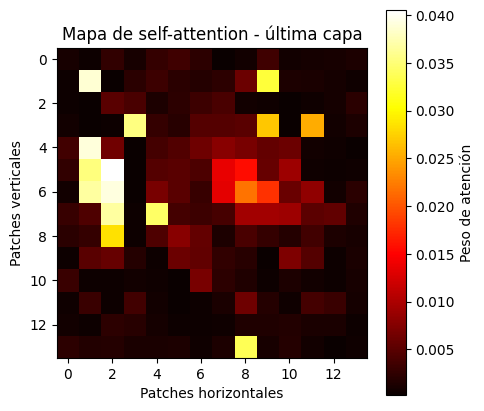

In [ ]:
# Visualizar el mapa de atención promedio

attention_map_np_1 = attention_map_1.detach().cpu().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(attention_map_np_1, cmap="hot", interpolation="nearest")
plt.colorbar(label="Peso de atención")
plt.title("Mapa de self-attention - última capa")
plt.xlabel("Patches horizontales")
plt.ylabel("Patches verticales")
plt.show()

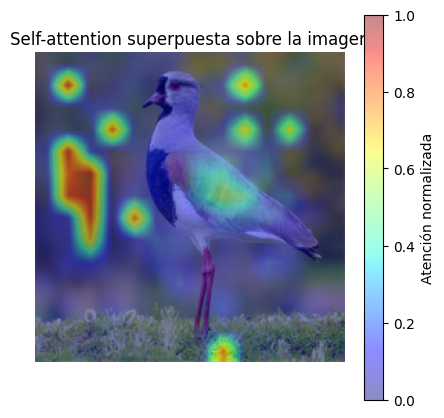

In [ ]:
# Superponer el mapa de atención sobre la imagen original

# Llevar el mapa a formato tensor [1, 1, 14, 14]
attention_tensor_1 = attention_map_1.unsqueeze(0).unsqueeze(0)

# Redimensionar el mapa de 14x14 a 224x224
attention_resized_1 = F.interpolate(
    attention_tensor_1,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

# Convertir a numpy
attention_resized_np_1 = (
    attention_resized_1
    .squeeze()
    .detach()
    .cpu()
    .numpy()
)

# Normalizar entre 0 y 1 para facilitar la visualización
attention_resized_np_1 = (
    attention_resized_np_1 - attention_resized_np_1.min()
) / (
    attention_resized_np_1.max() - attention_resized_np_1.min()
)

# Redimensionar la imagen original a 224x224
image_display_1 = image_1.resize((224, 224))

# Mostrar imagen y mapa de atención
plt.figure(figsize=(5, 5))

plt.imshow(image_display_1)

plt.imshow(
    attention_resized_np_1,
    cmap="jet",
    alpha=0.45
)

plt.colorbar(label="Atención normalizada")
plt.title("Self-attention superpuesta sobre la imagen")
plt.axis("off")
plt.show()

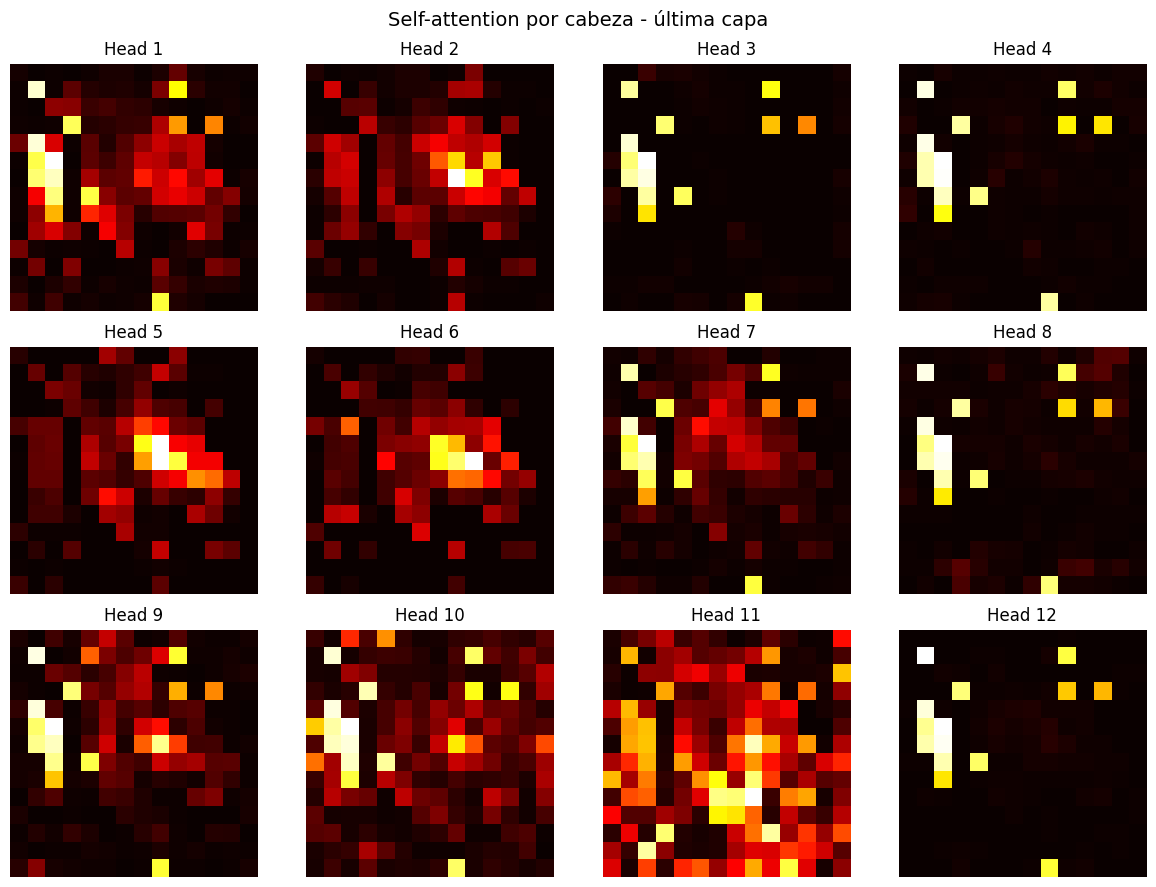

In [ ]:
# Visualizar individualmente las 12 cabezas de atención

heads_attention_1 = cls_attention_1[0].detach().cpu()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for head in range(12):
    head_map = heads_attention_1[head].reshape(14, 14)

    ax = axes.flat[head]
    im = ax.imshow(
        head_map,
        cmap="hot",
        interpolation="nearest"
    )

    ax.set_title(f"Head {head + 1}")
    ax.axis("off")

plt.suptitle(
    "Self-attention por cabeza - última capa",
    fontsize=14
)

plt.tight_layout()
plt.show()

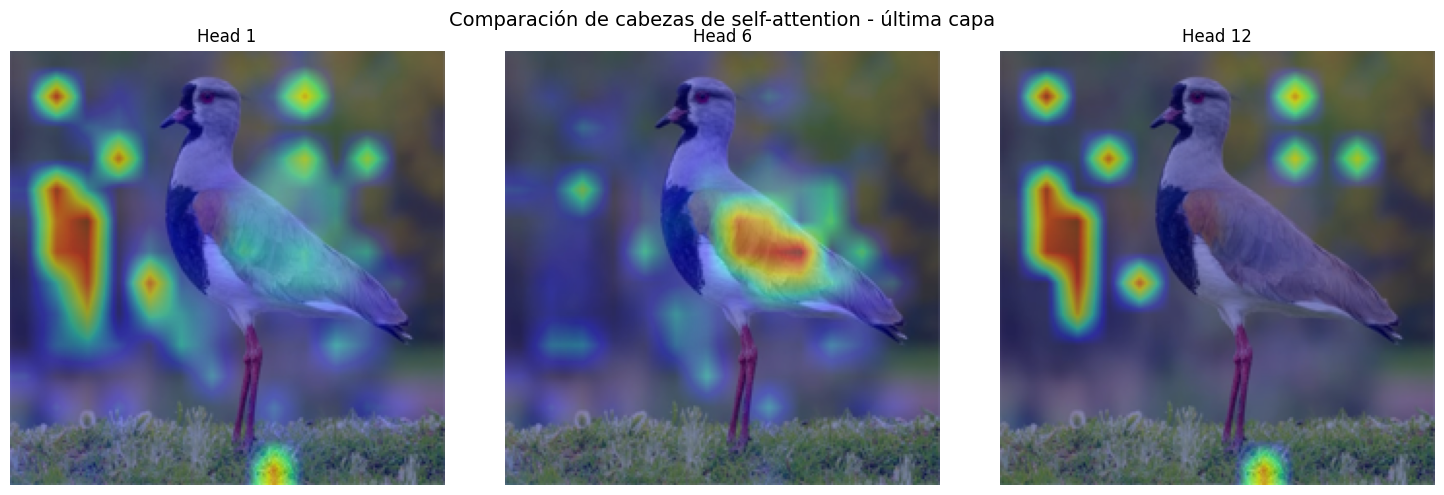

In [ ]:
# Superponer las cabezas individuales sobre la imagen

heads_to_show = [0, 5, 11]  # Heads 1, 6 y 12

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, head in zip(axes, heads_to_show):

    head_map = cls_attention_1[0, head].reshape(14, 14)

    head_tensor = head_map.unsqueeze(0).unsqueeze(0)

    head_resized = F.interpolate(
        head_tensor,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    head_np = (
        head_resized
        .squeeze()
        .detach()
        .cpu()
        .numpy()
    )

    # Normalización
    head_np = (head_np - head_np.min()) / (
        head_np.max() - head_np.min()
    )

    ax.imshow(image_display_1)

    ax.imshow(
        head_np,
        cmap="jet",
        alpha=0.45
    )

    ax.set_title(f"Head {head + 1}")
    ax.axis("off")

plt.suptitle(
    "Comparación de cabezas de self-attention - última capa",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Interpretación del ejemplo 1

Los mapas de self-attention muestran que las distintas cabezas de la última
capa no distribuyen su atención de forma idéntica. En particular, la cabeza 6
presenta una concentración clara sobre la región correspondiente al cuerpo y
ala del ave, mientras que las cabezas 1 y 12 asignan parte importante de su
atención a regiones del fondo.

El mapa obtenido al promediar las 12 cabezas refleja esta combinación de
patrones, mostrando atención tanto sobre el objeto principal como sobre
determinadas zonas del contexto.

Estos resultados son coherentes con el mecanismo de multi-head attention,
en el que distintas cabezas pueden capturar relaciones visuales diferentes.
Por tanto, los mapas deben interpretarse como pesos de atención asociados a
los distintos patches y no necesariamente como una explicación causal de la
predicción final.

### 3.2. Ejemplo 2: imagen de un vehículo

Tamaño original: (1649, 769)
Modo de color: RGB


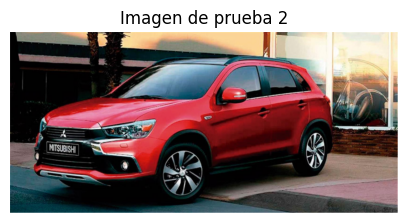

In [ ]:
# Cargar y visualizar la segunda imagen

image_2 = Image.open("imagen_auto1.jpg").convert("RGB")

print("Tamaño original:", image_2.size)
print("Modo de color:", image_2.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image_2)
plt.axis("off")
plt.title("Imagen de prueba 2")
plt.show()

In [ ]:
# Preprocesamiento de la segunda imagen

inputs_2 = processor(
    images=image_2,
    return_tensors="pt"
)

pixel_values_2 = inputs_2["pixel_values"]

print("Forma del tensor de entrada:", pixel_values_2.shape)
print("Tipo de datos:", pixel_values_2.dtype)
print("Valor mínimo:", pixel_values_2.min().item())
print("Valor máximo:", pixel_values_2.max().item())
print("Media:", pixel_values_2.mean().item())
print("Desviación estándar:", pixel_values_2.std().item())

Forma del tensor de entrada: torch.Size([1, 3, 224, 224])
Tipo de datos: torch.float32
Valor mínimo: -1.0
Valor máximo: 1.0
Media: -0.3422904908657074
Desviación estándar: 0.6059672832489014


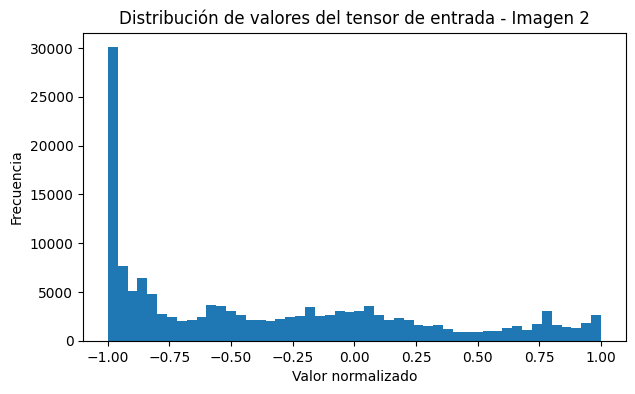

In [ ]:
# Distribución del tensor de entrada de la imagen 2

values_2 = pixel_values_2.cpu().numpy().flatten()

plt.figure(figsize=(7, 4))
plt.hist(values_2, bins=50)
plt.title("Distribución de valores del tensor de entrada - Imagen 2")
plt.xlabel("Valor normalizado")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Inferencia, logits y Top-5 de la imagen 2

pixel_values_2 = pixel_values_2.to(device)

with torch.no_grad():
    outputs_2 = model(pixel_values=pixel_values_2)

logits_2 = outputs_2.logits

print("Forma de los logits:", logits_2.shape)
print("Valor mínimo:", logits_2.min().item())
print("Valor máximo:", logits_2.max().item())
print("Media:", logits_2.mean().item())
print("Desviación estándar:", logits_2.std().item())

# Convertir logits en probabilidades
probabilities_2 = torch.softmax(logits_2, dim=1)

# Obtener las 5 clases con mayor probabilidad
top5_probs_2, top5_indices_2 = torch.topk(
    probabilities_2,
    k=5,
    dim=1
)

print("\nTop-5 predicciones:\n")

for i in range(5):
    class_id = top5_indices_2[0, i].item()
    probability = top5_probs_2[0, i].item()
    class_name = model.config.id2label[class_id]

    print(
        f"{i+1}. {class_name} "
        f"- probabilidad: {probability:.4f} "
        f"({probability*100:.2f}%)"
    )

Forma de los logits: torch.Size([1, 1000])
Valor mínimo: -2.321763753890991
Valor máximo: 9.280641555786133
Media: -8.62407705426449e-06
Desviación estándar: 1.0650067329406738

Top-5 predicciones:

1. pickup, pickup truck - probabilidad: 0.5239 (52.39%)
2. minivan - probabilidad: 0.0942 (9.42%)
3. jeep, landrover - probabilidad: 0.0903 (9.03%)
4. sports car, sport car - probabilidad: 0.0537 (5.37%)
5. grille, radiator grille - probabilidad: 0.0505 (5.05%)


In [ ]:
# Extracción de self-attention para la imagen 2

with torch.no_grad():
    outputs_attn_2 = model(
        pixel_values=pixel_values_2,
        output_attentions=True
    )

attentions_2 = outputs_attn_2.attentions

print("Número de capas con atención:", len(attentions_2))

for i, attention in enumerate(attentions_2):
    print(f"Capa {i+1}: {attention.shape}")

Número de capas con atención: 12
Capa 1: torch.Size([1, 12, 197, 197])
Capa 2: torch.Size([1, 12, 197, 197])
Capa 3: torch.Size([1, 12, 197, 197])
Capa 4: torch.Size([1, 12, 197, 197])
Capa 5: torch.Size([1, 12, 197, 197])
Capa 6: torch.Size([1, 12, 197, 197])
Capa 7: torch.Size([1, 12, 197, 197])
Capa 8: torch.Size([1, 12, 197, 197])
Capa 9: torch.Size([1, 12, 197, 197])
Capa 10: torch.Size([1, 12, 197, 197])
Capa 11: torch.Size([1, 12, 197, 197])
Capa 12: torch.Size([1, 12, 197, 197])


In [ ]:
# Mapa promedio del self-attention para la imagen 2

last_attention_2 = attentions_2[-1]

# Atención del token CLS hacia los 196 patches
cls_attention_2 = last_attention_2[:, :, 0, 1:]

print("Forma atención CLS -> patches:", cls_attention_2.shape)

# Promedio entre las 12 cabezas
mean_cls_attention_2 = cls_attention_2.mean(dim=1)

print("Forma después de promediar cabezas:", mean_cls_attention_2.shape)

# Reorganizar los 196 valores como matriz 14x14
attention_map_2 = mean_cls_attention_2.reshape(14, 14)

print("Forma del mapa de atención:", attention_map_2.shape)

Forma atención CLS -> patches: torch.Size([1, 12, 196])
Forma después de promediar cabezas: torch.Size([1, 196])
Forma del mapa de atención: torch.Size([14, 14])


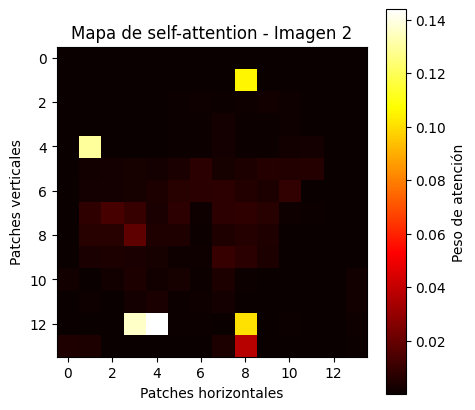

In [ ]:
# Visualización del mapa de self-attention promedio de la imagen 2

attention_map_np_2 = attention_map_2.detach().cpu().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(attention_map_np_2, cmap="hot", interpolation="nearest")
plt.colorbar(label="Peso de atención")
plt.title("Mapa de self-attention - Imagen 2")
plt.xlabel("Patches horizontales")
plt.ylabel("Patches verticales")
plt.show()

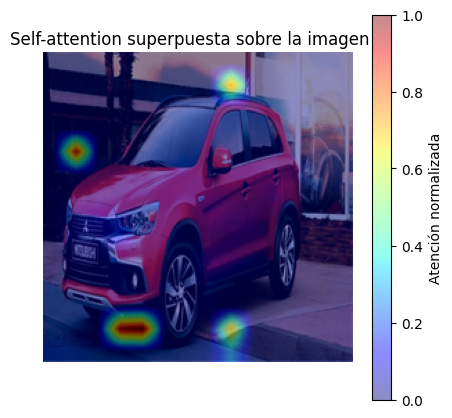

In [ ]:
# Superponer el mapa de atención sobre la imagen 2

# Llevar el mapa a formato tensor [1, 1, 14, 14]
attention_tensor_2 = attention_map_2.unsqueeze(0).unsqueeze(0)

# Redimensionar de 14x14 a 224x224
attention_resized_2 = F.interpolate(
    attention_tensor_2,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

# Convertir a numpy
attention_resized_np_2 = (
    attention_resized_2
    .squeeze()
    .detach()
    .cpu()
    .numpy()
)

# Normalizar entre 0 y 1
attention_resized_np_2 = (
    attention_resized_np_2 - attention_resized_np_2.min()
) / (
    attention_resized_np_2.max() - attention_resized_np_2.min()
)

# Redimensionar imagen original
image_display_2 = image_2.resize((224, 224))

# Superposición
plt.figure(figsize=(5, 5))

plt.imshow(image_display_2)

plt.imshow(
    attention_resized_np_2,
    cmap="jet",
    alpha=0.45
)

plt.colorbar(label="Atención normalizada")
plt.title("Self-attention superpuesta sobre la imagen 2")
plt.axis("off")

plt.show()

### Interpretación del ejemplo 2

Para la segunda imagen, el modelo obtuvo como predicción principal
`pickup, pickup truck`, con una probabilidad del 52,39 %, mostrando una
confianza mayor que en el primer ejemplo.

El mapa promedio de self-attention muestra pesos relevantes tanto sobre
regiones del vehículo como sobre determinadas zonas del contexto. Se observan
máximos de atención próximos al techo y a la zona inferior del automóvil,
mientras que otras áreas del fondo también reciben atención significativa.

Al igual que en el primer ejemplo, esto indica que las distintas cabezas pueden
capturar patrones visuales diferentes y que el mapa promedio representa la
combinación de esas distribuciones de atención.

### 3.3. Comparación entre ejemplos

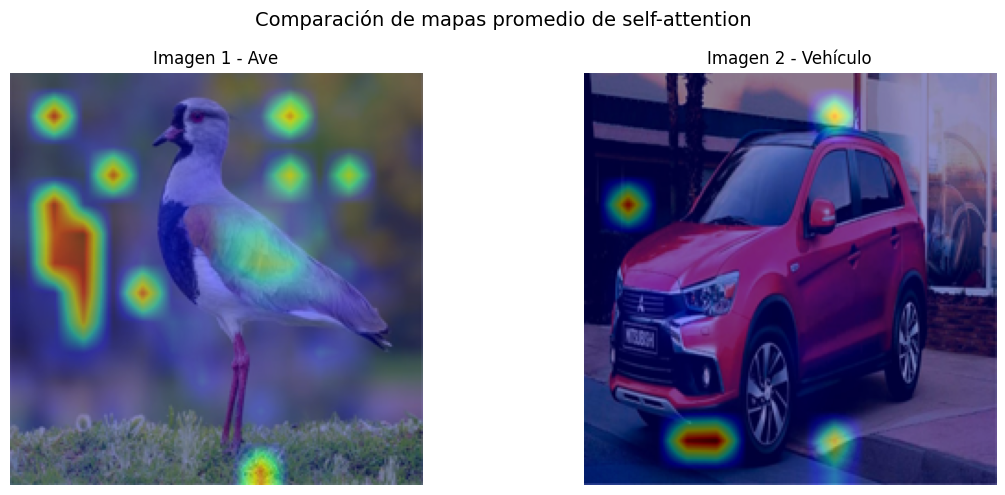

In [ ]:
# Comparación entre los dos ejemplos

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Para la Imagen 1
axes[0].imshow(image_display_1)
axes[0].imshow(
    attention_resized_np_1,
    cmap="jet",
    alpha=0.45
)
axes[0].set_title("Imagen 1 - Ave")
axes[0].axis("off")

# Para la Imagen 2
axes[1].imshow(image_display_2)
axes[1].imshow(
    attention_resized_np_2,
    cmap="jet",
    alpha=0.45
)
axes[1].set_title("Imagen 2 - Vehículo")
axes[1].axis("off")

plt.suptitle(
    "Comparación de mapas promedio de self-attention",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Comparación de los dos ejemplos

Los dos casos muestran que la atención no se concentra exclusivamente sobre el
objeto principal. En la imagen del ave se observa una mayor dispersión de la
probabilidad entre varias clases similares, mientras que en la imagen del
vehículo la predicción principal presenta una confianza superior.

Los mapas de self-attention evidencian además que el modelo utiliza tanto
información del objeto como del contexto, aunque la distribución espacial de
la atención cambia entre ambas imágenes.

## Conclusiones

En esta actividad se analizó una implementación preentrenada de la arquitectura
Vision Transformer (ViT-B/16), utilizando el modelo
`google/vit-base-patch16-224`.

El análisis de la arquitectura confirmó que el modelo procesa imágenes RGB de
224×224 píxeles, divididas en 196 patches de 16×16. Tras incorporar el token
de clasificación `[CLS]`, la secuencia queda compuesta por 197 tokens con una
dimensión oculta de 768. El modelo utiliza 12 bloques Transformer, 12 cabezas
de atención y aproximadamente 86,6 millones de parámetros.

Para los dos ejemplos analizados, el tensor de entrada presentó la forma
`[1, 3, 224, 224]`, mientras que la salida estuvo constituida por 1000 logits,
uno por cada clase de ImageNet. En la primera imagen, correspondiente a un ave,
el modelo distribuyó la probabilidad entre varias clases visualmente similares.
En la segunda imagen, correspondiente a un vehículo, la predicción fue más
concentrada, obteniéndose como primera clase `pickup, pickup truck`.

El análisis de self-attention mostró que las distintas cabezas no concentran
su atención en las mismas regiones. Algunas presentan mayor peso sobre partes
del objeto principal, mientras que otras también atienden a elementos del
contexto. El promedio de las 12 cabezas refleja esta combinación de patrones.

En consecuencia, los resultados permiten observar cómo Vision Transformer representa una imagen como una secuencia de patches y utiliza mecanismos de self-attention para relacionar distintas regiones espaciales. Finalmente, la representación obtenida es utilizada por la cabeza de clasificación para generar los logits de salida.